## First... what exactly are we doing? 

we use Mass Spec which generates lots of data per file (thinking of ~500 peaks on the normal LC-MS run). With this amount of data, Excel cannot handle this or at a low speed due to memory issue.

you can choose:
 - MATLAB is great for matrix calculation (and fast) but a bit hard to use (i.e., go find a script from someone else, save it, and try importing it when one function = one file). in contrast, the Pandas package in Python provide most of the tool you need for modifying a dataframe (basically a table) and you only need  to import the package once.
 - Atmospheric chemists like Igor, which can do some calculation, but mostly on plotting the data
 - or other programming language like python, which does lots of stuff and easier to read 


we're using the Jupyter Notebook which allows to have markdown (plain texts) and code block which you can see the result directly

each cell has a number on the bottom left side of the cell, though usually the code cell will show the number but markdown cell will hide it after editing.

depends on the setting, you can use `Shift + Enter` to run the cell when you click it, or press the triangle on the top left cornor of the cell.

the code cell can have output that show up under the cell. This will help you to know what's happening in the code or the results of it



__________________________________________________________________________________________
without really going into Python's basic (data types, syntax etc, if you want check out the 0_python_quick_start file), we're only going to talk about how we go from tables (like an excel file) to what to work with

but first we still need to get some basic stuff first lol 😉





all python file usualy starts with import or some description. import simply means that in this file im going to import some function or pacakge install already so i can use them. 

some package are install with python already:
- **os** , **sys**... etc

some you need to install 
- **pandas**, **numpy**, **matplotlib**... etc 

you may use the `requirements.txt` to install everything you need if provided
if you're using your own computer, go to the folder where  `requirements.txt` is located
open terminal,  and type ```pip install -r requirements.txt```

or if you're using Google Colab, use ```!pip install -r requirements.txt```


when you import, you can keep the package name as it is, or you can rename the package so you dont need to type the entire name when you use it
- for example: instead of pandas, you can use `import pandas as pd` and use **pd** in the code


whenever you need to see something, the function `print()` will get what you need

In [1]:
import os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

print("package loaded!")

package loaded!


most of the time `pandas` is the one working with table and `numpy` works with an array of values and calculations

Here, we can make a simple table by  `DataFrame` (note that D and F are capped)

The good thing about pandas or other python package for data is that it can hold much more data then excel without much issue (where excel capped ~1million)

In [2]:
df = pd.DataFrame({'RT': [1.1, 1.5, 1.9, 2.5], 
                   'm/z':[120.2334, 195.0877, 203.5836, 188.2937],
                   "intensity":[10000, 299949, 1999, 24555555]})
df

,RT,m/z,intensity
0,1.1,120.2334,10000
1,1.5,195.0877,299949
2,1.9,203.5836,1999
3,2.5,188.2937,24555555


if we want to convert the rt to sec, we can simply multiple the entire column by 60 

- in excel it usually requires to create a new column...


we can also do some calculation on the column as well lie normalization

In [5]:
df["RT"] = df["RT"] * 60
df['Normalized_Intensity'] = df['intensity'] / df['intensity'].max()
df

,RT,m/z,intensity,Normalized_Intensity
0,3960.0,120.2334,10000,0.000407
1,5400.0,195.0877,299949,0.012215
2,6840.0,203.5836,1999,0.000081
3,9000.0,188.2937,24555555,1.000000


we can of course do simple graph form the dataframe 
* directly plot it with the dataframe which works on `df` 

* or we call matplotlib package to do the graph.

* seaborn is another graphing package on top of matplotlib and make better graphs, but we're not going to use it for now


for more graphes check out the _graphes.ipynb notebook. we wont go too much about it here 

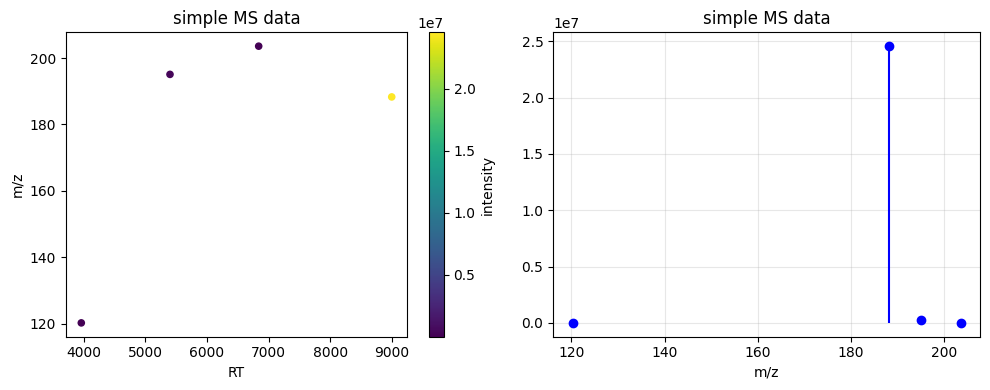

In [10]:
fig, axes = plt.subplots(1,2, figsize = (10,4)) # subplots allows you to plot several things within the same graph


# the colormap which based on matplotlib package, can find more in https://matplotlib.org/stable/users/explain/colors/colormaps.html
df.plot(x="RT", 
        y="m/z",
        title="simple MS data",
        kind='scatter', # we want scatter here, but you can do "line", "bar", "pit".. etc
        c='intensity',  # we want the color based on the column 'intensity'
        colormap='viridis',
        ax=axes[0]) 

# s = axes[1].scatter(df["RT"], df["m/z"], c=df["intensity"], cmap='viridis')
# fig.colorbar(s)

plt.stem(df['m/z'], df['intensity'], linefmt='b-', markerfmt='bo', basefmt=' ',bottom=0)

axes[1].set_title("simple MS data")
axes[1].set_xlabel("m/z")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

in python the major two ploting packages are `matplotlib` (more specifically matplotlib.pyplot) and `seaborn`

- matplotlib is the basic engine. you could control mostly everything you wanted on the plot


- seaborn is based on matplotlib but provide easier operation (or it's more like a designer who handles dataframe and stats). 


rule of thumb: use whichever you're familiar with, or search if either porivde similar plot you wanted. for numeric data it's fine for matplotlib. but if you have some sort of categorical data (like sample types, time etc) or you need some sort of stats related plot (box plot etc) seaborn can be easy to use





--------------------------------------------------------
lets say we have some calibration curve and measured three times...

In [57]:

cal_data = pd.DataFrame({
    'Concentration': [0.5, 1.0, 5.0, 10.0, 50.0,
                      0.5, 1.0, 5.0, 10.0, 50.0,
                      0.5, 1.0, 5.0, 10.0, 50.0],
    'Peak_Area': [1200, 2450, 11800, 23900, 120500, 
                  1150, 2475, 11905,24000, 121662,
                  1209,2444,11783,24576,119999]
})

cal_data

,Concentration,Peak_Area
0,0.5,1200
1,1.0,2450
2,5.0,11800
3,10.0,23900
4,50.0,120500
5,0.5,1150
6,1.0,2475
7,5.0,11905
8,10.0,24000
9,50.0,121662


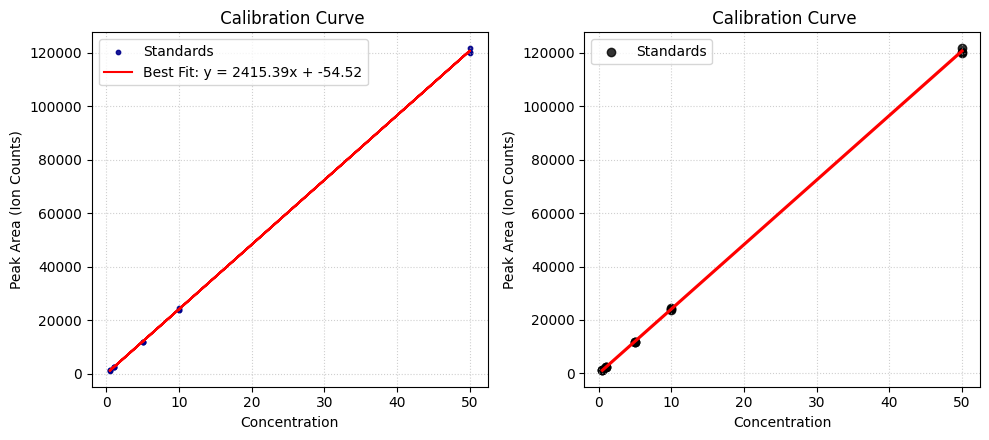

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1,2, figsize = (10,4.5)) 

#1 we start with matplotlib first 
m, c = np.polyfit(cal_data['Concentration'], cal_data["Peak_Area"], 1) # simply linear regression
axes[0].scatter(cal_data['Concentration'], cal_data['Peak_Area'], 
                color='darkblue', marker='o', label='Standards', 
                s=10, alpha = 0.9)
axes[0].plot(cal_data['Concentration'], m * cal_data['Concentration'] + c, 
             color="red", label=f"Best Fit: y = {m:.2f}x + {c:.2f}")

axes[0].set_title(' Calibration Curve')
axes[0].set_xlabel('Concentration')
axes[0].set_ylabel('Peak Area (Ion Counts)')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# 2, then we can try with seaborn's regplot which handles the regression... 
# but it's weird how it doesnt like to output the equation etc and it's not so obvious to get them
sns.regplot(data=cal_data, x="Concentration", y="Peak_Area", ax=axes[1],label='Standards',
            color='black', line_kws=dict(color="r"), ci=95)
axes[1].set_title(' Calibration Curve')
axes[1].set_xlabel('Concentration')
axes[1].set_ylabel('Peak Area (Ion Counts)')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout() # this make sure that the elements from two plots appear properly
plt.show()

In [67]:
cal_data_Stats = cal_data.groupby('Concentration')["Peak_Area"].agg(["mean","median","std"]).reset_index()
cal_data_Stats

,Concentration,mean,median,std
0,0.5,1186.333333,1200.0,31.785741
1,1.0,2456.333333,2450.0,16.441817
2,5.0,11829.333333,11800.0,66.078236
3,10.0,24158.666667,24000.0,364.863445
4,50.0,120720.333333,120500.0,853.113318


now we can have the error bar as well

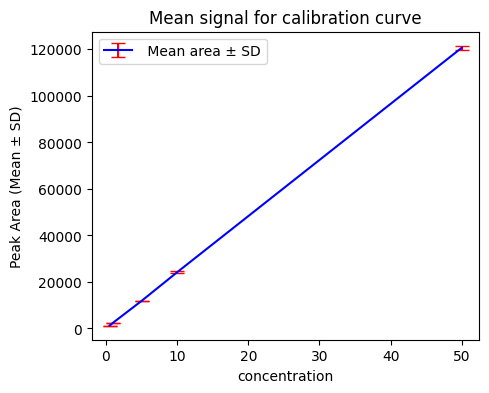

In [81]:
plt.figure(figsize=(5, 4))

plt.errorbar(
    x=cal_data_Stats['Concentration'], 
    y=cal_data_Stats['mean'], 
    yerr=cal_data_Stats['std'],        
    color='b', 
    ecolor='red',                
    capsize=5,                   
    label=' Mean area ± SD'
)

plt.title('Mean signal for calibration curve')
plt.xlabel('concentration')
plt.ylabel('Peak Area (Mean ± SD)')
plt.legend()
plt.show()